# K-Nearest Neighbors (KNN): A Comprehensive Guide

K-Nearest Neighbors is one of the simplest and most intuitive machine learning algorithms. It classifies a data point based on how its neighbors are classified — the majority vote of the K nearest data points.

In this notebook, we'll cover:
1. Basic concepts of KNN
2. Data preparation and visualization
3. Model implementation from scratch
4. Using scikit-learn for KNN
5. Model evaluation and interpretation

# Simple Explanation: What Does the Code Below Do?

Imagine you move to a new city and want to know what neighborhood you're in. You look at the K nearest houses and see which neighborhood the majority belong to — that's your neighborhood too! KNN works exactly the same way.

- **K**: The number of neighbors to look at.
- **Distance metric**: Usually Euclidean distance (straight line distance).
- **Prediction**: Take the majority class among the K nearest points.

Here's what the code does:
1. Uses the Iris dataset for multi-class classification.
2. Implements KNN from scratch with distance calculations.
3. Uses scikit-learn's KNN and finds the optimal K value.
4. Visualizes decision boundaries for different K values.

In short: KNN is a lazy learner — it doesn't build a model, it just memorizes training data and finds the closest examples at prediction time!

In [1]:
# Create a virtual environment and install required libraries
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed in the virtual environment.')
else:
    print('Could not find pip in the virtual environment. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed in the virtual environment.


# 1. Required Libraries

Let's start by importing the necessary libraries:
- NumPy: For numerical computations
- Pandas: For data manipulation
- Matplotlib: For basic plotting
- Seaborn: For statistical visualizations
- Scikit-learn: For machine learning tools

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter

# Set the style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

We'll use the Iris dataset with only 2 features (petal length & width) for easy 2D visualization of decision boundaries.

Dataset shape: (150, 2)
Features used: petal length, petal width


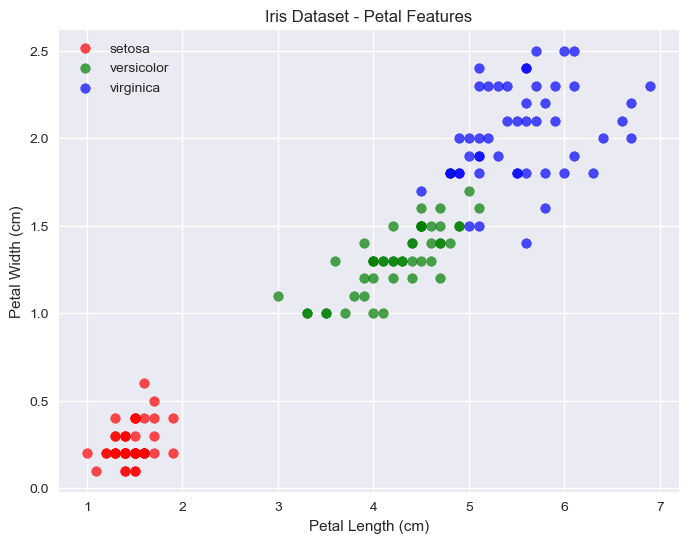

In [3]:
# Load dataset
iris = load_iris()
# Use only petal features for visualization
X = iris.data[:, 2:4]  # petal length, petal width
y = iris.target
class_names = iris.target_names

print('Dataset shape:', X.shape)
print('Features used: petal length, petal width')

# Scale features (important for KNN!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Visualize the data
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
for i, species in enumerate(class_names):
    mask = y == i
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[i], label=species, alpha=0.7)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Dataset - Petal Features')
plt.legend()
plt.grid(True)
plt.show()

# 3. Implementing KNN from Scratch

The algorithm is simple:
1. Calculate the Euclidean distance from the query point to every training point.
2. Sort by distance and pick the K nearest neighbors.
3. Return the most common class among the K neighbors (majority vote).

In [4]:
class KNNScratch:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """KNN doesn't train — it just stores the training data."""
        self.X_train = X
        self.y_train = y

    def _euclidean_distance(self, x1, x2):
        """Calculate Euclidean distance between two points."""
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def _predict_single(self, x):
        """Predict class for a single point."""
        # Calculate distances to all training points
        distances = [self._euclidean_distance(x, x_train) for x_train in self.X_train]
        # Get K nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        k_labels = [self.y_train[i] for i in k_indices]
        # Majority vote
        most_common = Counter(k_labels).most_common(1)
        return most_common[0][0]

    def predict(self, X):
        return np.array([self._predict_single(x) for x in X])

# Test with K=3
knn_scratch = KNNScratch(k=3)
knn_scratch.fit(X_train, y_train)
y_pred_scratch = knn_scratch.predict(X_test)

print(f'KNN from Scratch (K=3) Accuracy: {accuracy_score(y_test, y_pred_scratch):.4f}')

KNN from Scratch (K=3) Accuracy: 1.0000


# 4. Using Scikit-learn's KNN

Let's use sklearn's KNN and find the optimal K using cross-validation.

In [5]:
# Find best K using cross-validation
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
print(f'Best K: {best_k} with CV Accuracy: {max(cv_scores):.4f}')

# Train optimal model
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred = knn_best.predict(X_test)

print(f'\nTest Accuracy (K={best_k}): {accuracy_score(y_test, y_pred):.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred, target_names=class_names)}')

Best K: 1 with CV Accuracy: 0.9583

Test Accuracy (K=1): 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# 5. Model Evaluation

Let's visualize the decision boundaries for different K values and evaluate the final model.

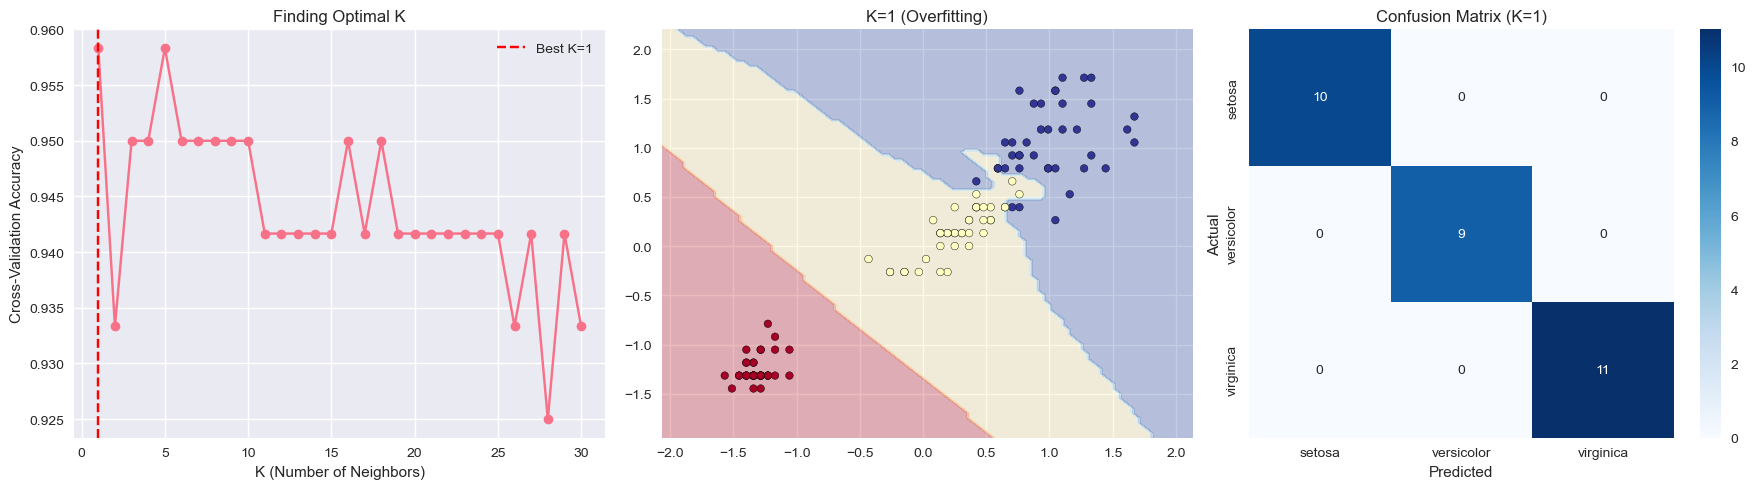


Key Insights:
- Small K (e.g., K=1): Very complex boundary, prone to overfitting.
- Large K: Smoother boundary, prone to underfitting.
- Always scale features before applying KNN!


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. CV Accuracy vs K
axes[0].plot(k_range, cv_scores, marker='o')
axes[0].axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[0].set_xlabel('K (Number of Neighbors)')
axes[0].set_ylabel('Cross-Validation Accuracy')
axes[0].set_title('Finding Optimal K')
axes[0].legend()
axes[0].grid(True)

# 2. Decision Boundaries for K=1 vs K=best_k
def plot_boundaries(ax, knn, X, y, title):
    h = 0.05
    x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
    y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k', s=30)
    ax.set_title(title)

knn1 = KNeighborsClassifier(n_neighbors=1).fit(X_train, y_train)
plot_boundaries(axes[1], knn1, X_train, y_train, 'K=1 (Overfitting)')

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, 
            yticklabels=class_names, ax=axes[2])
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_title(f'Confusion Matrix (K={best_k})')

plt.tight_layout()
plt.show()

print('\nKey Insights:')
print('- Small K (e.g., K=1): Very complex boundary, prone to overfitting.')
print('- Large K: Smoother boundary, prone to underfitting.')
print('- Always scale features before applying KNN!')

# Conclusions and Key Takeaways
K-Nearest Neighbors (k-NN) is a simple, intuitive, non-parametric algorithm used for classification and regression. It makes predictions based on the proximity (similarity) of data points.
- **Lazy Learner**: Doesn't actually "train" a model during the training phase. It simply memorizes the dataset and performs all computations at prediction time.
- **Distance Metrics**: Relies heavily on metrics like Euclidean, Manhattan, or Minkowski distance. K determines how many neighbors vote on the prediction.

# Pros and Cons
**Pros:**
- extremely simple to understand and implement.
- No training time required; new data can be added seamlessly.
- Naturally handles multi-class classification environments.

**Cons:**
- High prediction cost (computational and memory) since it must compute the distance to every training sample for every new prediction.
- Degrades rapidly in high dimensional spaces due to the "Curse of Dimensionality".
- Highly sensitive to irrelevant features and the scale of the features.

# 15 Interview Questions and Answers

1. **How does the k-NN algorithm work?**
   *Answer*: For a given new instance, it computes the distance between that instance and all instances in the training set, selects the 'k' nearest neighbors, and assigns the majority class label (for classification) or the average value (for regression).

2. **Why is k-NN called a "lazy learner"?**
   *Answer*: Because it defers all the computation to the prediction phase. During the training phase, it essentially just stores the data without building a generalized internal model.

3. **What distance metrics are commonly used in k-NN?**
   *Answer*: Euclidean distance is the most common. Others include Manhattan (L1), Minkowski, and Cosine similarity (often used for text/high-dimensional sparsity).

4. **How do you choose the value of 'k'?**
   *Answer*: Using cross-validation. A small 'k' leads to a complex model (high variance, prone to overfitting to noise), while a large 'k' leads to a simpler model (high bias, overly smooth decision boundaries). 'k' is usually an odd number to avoid ties.

5. **Is feature scaling necessary for k-NN?**
   *Answer*: Absolutely. Because it relies on distance metrics, a feature with a larger range of values (e.g., Salary in thousands vs Age in tens) will completely dominate the distance calculation if the data is not normalized or standardized.

6. **What is the Curse of Dimensionality in the context of k-NN?**
   *Answer*: As the number of dimensions/features increases, the volume of the space increases exponentially, making the data very sparse. In high-dimensional space, the concept of "distance" becomes meaningless because the distance to the nearest neighbor approaches the distance to the farthest data point.

7. **How does k-NN handle outliers?**
   *Answer*: It is quite sensitive to outliers, especially for very small values of 'k' (like k=1). If a new point lies near an outlier, it might be classified incorrectly. Increasing 'k' mitigates this.

8. **How does k-NN handle categorical variables?**
   *Answer*: It struggles natively. They must be one-hot encoded (which increases dimensionality) or handled using specific distance metrics like Hamming distance for categorical mismatches.

9. **What is weighted k-NN?**
   *Answer*: Instead of a simple majority vote, neighbors are assigned a weight proportional to the inverse of their distance to the query point. Closer neighbors have a stronger influence on the prediction than distant ones.

10. **How does the time complexity of k-NN scale?**
    *Answer*: Worst case prediction time is O(N * D), where N is the number of training samples and D is the number of dimensions. This makes it unscalable for massive datasets.

11. **How can you speed up k-NN prediction time?**
    *Answer*: By using spatial data structures like KD-Trees or Ball-Trees, which partition the space to avoid computing distances to every single point. However, these degrade to brute-force speed in higher dimensions.

12. **Can k-NN be used for missing value imputation?**
    *Answer*: Yes, k-NN imputation is very popular. It predicts missing feature values based on the values of those features in the nearest neighboring samples in the multidimensional space.

13. **Is k-NN a parametric or non-parametric algorithm?**
    *Answer*: Non-parametric. It makes zero explicit assumptions about the functional form or distribution of the underlying data.

14. **What happens if k equals the total number of data points?**
    *Answer*: The model will simply always predict the majority class of the entire dataset, ignoring the input features completely. This represents a model with maximum bias.

15. **Why should k preferably be an odd number in binary classification?**
    *Answer*: To eliminate the possibility of a tie vote between the two classes when making a prediction.
